In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/bonus_dataset.csv")

In [3]:
df.head()

,employee_id,performance,years_of_exp,proj_completed,bonus
0,EMP_001,9,1,2,138
1,EMP_002,7,3,6,134
2,EMP_003,1,4,5,66
3,EMP_004,3,1,4,70
4,EMP_005,9,1,4,142


In [4]:
df.shape

(100, 5)

In [5]:
type(df.performance.values)

numpy.ndarray

In [6]:
performance = torch.tensor(df['performance'].values, dtype=torch.float32)
years_of_exp = torch.tensor(df['years_of_exp'].values, dtype=torch.float32)
proj_completed = torch.tensor(df['proj_completed'].values, dtype=torch.float32)
bonus = torch.tensor(df['bonus'].values, dtype=torch.float32)

In [7]:
w1 = torch.rand(1, requires_grad= True)
w2 = torch.rand(1, requires_grad= True)
w3 = torch.rand(1, requires_grad= True)
bias = torch.rand(1, requires_grad= True)
w1,w2,w3,bias

(tensor([0.0489], requires_grad=True),
 tensor([0.6117], requires_grad=True),
 tensor([0.9004], requires_grad=True),
 tensor([0.0691], requires_grad=True))

In [8]:
epochs = 5000
learning_rate = 0.005

loss_history1 = [] # list to store the loss at each epoch
for epoch in range(epochs):
  predicted_bonus = w1*performance + w2*years_of_exp + w3*proj_completed + bias

  loss1 = ((predicted_bonus - bonus)**2).mean()
  loss_history1.append(loss1.item())
  loss1.backward()
  with torch.no_grad():
    w1 -= learning_rate * w1.grad
    w2 -= learning_rate * w2.grad
    w3 -= learning_rate * w3.grad
    bias -= learning_rate * bias.grad

  w1.grad.zero_()
  w2.grad.zero_()
  w3.grad.zero_()
  bias.grad.zero_()

  if (epoch+1) % 100 == 0:
    print(f"Epoch: {epoch +1}/{epochs}, Loss: {loss1.item():.4f}")

Epoch: 100/5000, Loss: 21.8374
Epoch: 200/5000, Loss: 18.9280
Epoch: 300/5000, Loss: 16.5234
Epoch: 400/5000, Loss: 14.4661
Epoch: 500/5000, Loss: 12.6797
Epoch: 600/5000, Loss: 11.1191
Epoch: 700/5000, Loss: 9.7523
Epoch: 800/5000, Loss: 8.5542
Epoch: 900/5000, Loss: 7.5036
Epoch: 1000/5000, Loss: 6.5820
Epoch: 1100/5000, Loss: 5.7737
Epoch: 1200/5000, Loss: 5.0646
Epoch: 1300/5000, Loss: 4.4427
Epoch: 1400/5000, Loss: 3.8971
Epoch: 1500/5000, Loss: 3.4185
Epoch: 1600/5000, Loss: 2.9987
Epoch: 1700/5000, Loss: 2.6304
Epoch: 1800/5000, Loss: 2.3074
Epoch: 1900/5000, Loss: 2.0240
Epoch: 2000/5000, Loss: 1.7755
Epoch: 2100/5000, Loss: 1.5574
Epoch: 2200/5000, Loss: 1.3662
Epoch: 2300/5000, Loss: 1.1984
Epoch: 2400/5000, Loss: 1.0512
Epoch: 2500/5000, Loss: 0.9221
Epoch: 2600/5000, Loss: 0.8089
Epoch: 2700/5000, Loss: 0.7095
Epoch: 2800/5000, Loss: 0.6224
Epoch: 2900/5000, Loss: 0.5460
Epoch: 3000/5000, Loss: 0.4789
Epoch: 3100/5000, Loss: 0.4201
Epoch: 3200/5000, Loss: 0.3685
Epoch: 3300

In [9]:
len(loss_history1)

5000

In [10]:
print("The learned weight and bias:")

print(f"w1 : {w1.item():.2f},w2: {w2.item():.2f},w3: {w3.item():.2f},bias: {bias.item():.2f}")

The learned weight and bias:
w1 : 12.02,w2: 5.84,w3: 2.18,bias: 19.31


In [11]:
predicted_b = w1.item()*7 + w2.item()*3 + w3.item()* 6 + bias.item()
predicted_b

134.10368013381958

In [12]:
predicted_b = w1.item()*9 + w2.item()*1 + w3.item()* 4 + bias.item()
predicted_b

142.10340118408203

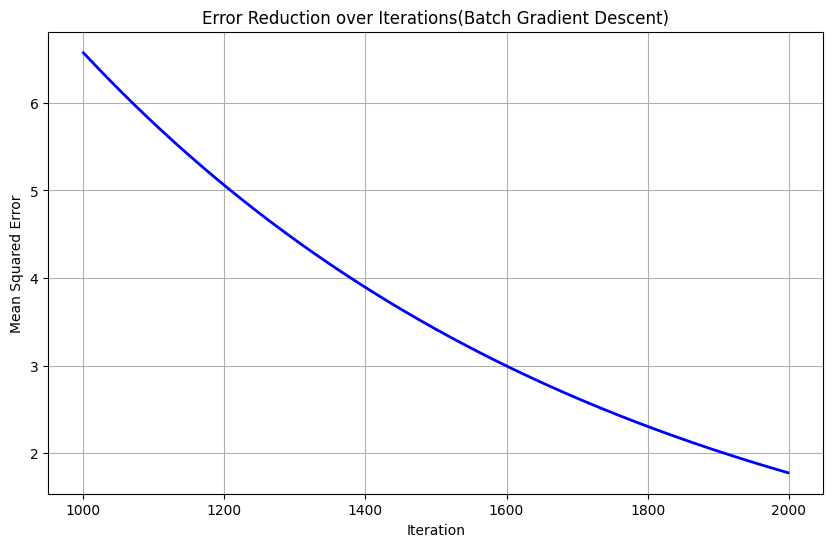

In [13]:
def plot_loss(epochs, loss_history1, title):
  plt.figure(figsize=(10,6))
  plt.plot(epochs, loss_history1, color='blue', linewidth=2)
  plt.title(title)
  plt.xlabel("Iteration")
  plt.ylabel("Mean Squared Error")
  plt.grid(True)
  plt.show()

plot_loss(range(1000,2000), loss_history1[1000:2000], "Error Reduction over Iterations(Batch Gradient Descent)")




**MINI BATCH**

In [14]:
w1 = torch.rand(1, requires_grad= True)
w2 = torch.rand(1, requires_grad= True)
w3 = torch.rand(1, requires_grad= True)
bias = torch.rand(1, requires_grad= True)
w1,w2,w3,bias

(tensor([0.4934], requires_grad=True),
 tensor([0.7040], requires_grad=True),
 tensor([0.1095], requires_grad=True),
 tensor([0.3111], requires_grad=True))

In [15]:
learning_rate = 0.001
epochs = 5000
batch_size = 16
loss_history2 = []
n_samples = len(performance)

for epoch in range(epochs):
  for i in range(0, n_samples, batch_size):
    batch_performance = performance[i:i + batch_size]
    batch_years_of_exp = years_of_exp[i:i + batch_size]
    batch_proj_completed = proj_completed[i:i + batch_size]
    batch_bonus = bonus[i:i + batch_size]

    predicted_bonus2 = w1* batch_performance + w2* batch_years_of_exp + w3* batch_proj_completed + bias

    loss2 = ((predicted_bonus2 - batch_bonus) **2).mean()
    loss_history2.append(loss2.item())

    loss2.backward()

    with torch.no_grad():
      w1-= learning_rate * w1.grad
      w2 -= learning_rate * w2.grad
      w3 -= learning_rate * w3.grad
      bias -= learning_rate * bias.grad

      w1.grad.zero_()
      w2.grad.zero_()
      w3.grad.zero_()
      bias.grad.zero_()

      if(epoch+1)% 100==0 :
        print(f"Epoch: [{epoch+1}/ {epochs}], Loss : {loss2.item():.4f}")

Epoch: [100/ 5000], Loss : 13.2589
Epoch: [100/ 5000], Loss : 13.9063
Epoch: [100/ 5000], Loss : 18.6680
Epoch: [100/ 5000], Loss : 19.0940
Epoch: [100/ 5000], Loss : 36.3249
Epoch: [100/ 5000], Loss : 15.0885
Epoch: [100/ 5000], Loss : 28.9552
Epoch: [200/ 5000], Loss : 10.8348
Epoch: [200/ 5000], Loss : 11.3264
Epoch: [200/ 5000], Loss : 16.1189
Epoch: [200/ 5000], Loss : 15.1065
Epoch: [200/ 5000], Loss : 28.8154
Epoch: [200/ 5000], Loss : 12.8083
Epoch: [200/ 5000], Loss : 22.2665
Epoch: [300/ 5000], Loss : 8.9950
Epoch: [300/ 5000], Loss : 9.4148
Epoch: [300/ 5000], Loss : 13.7119
Epoch: [300/ 5000], Loss : 12.3001
Epoch: [300/ 5000], Loss : 23.3415
Epoch: [300/ 5000], Loss : 10.8121
Epoch: [300/ 5000], Loss : 17.7077
Epoch: [400/ 5000], Loss : 7.4760
Epoch: [400/ 5000], Loss : 7.8371
Epoch: [400/ 5000], Loss : 11.5280
Epoch: [400/ 5000], Loss : 10.1120
Epoch: [400/ 5000], Loss : 19.0963
Epoch: [400/ 5000], Loss : 9.0563
Epoch: [400/ 5000], Loss : 14.3367
Epoch: [500/ 5000], Loss 

In [16]:
len(loss_history2)

35000

In [17]:
type(loss_history2[10000])

float

In [18]:
print("The learned weight and bias:")

print(f"w1 : {w1.item():.2f},w2: {w2.item():.2f},w3: {w3.item():.2f},bias: {bias.item():.2f}")

The learned weight and bias:
w1 : 12.00,w2: 5.96,w3: 2.04,bias: 19.85


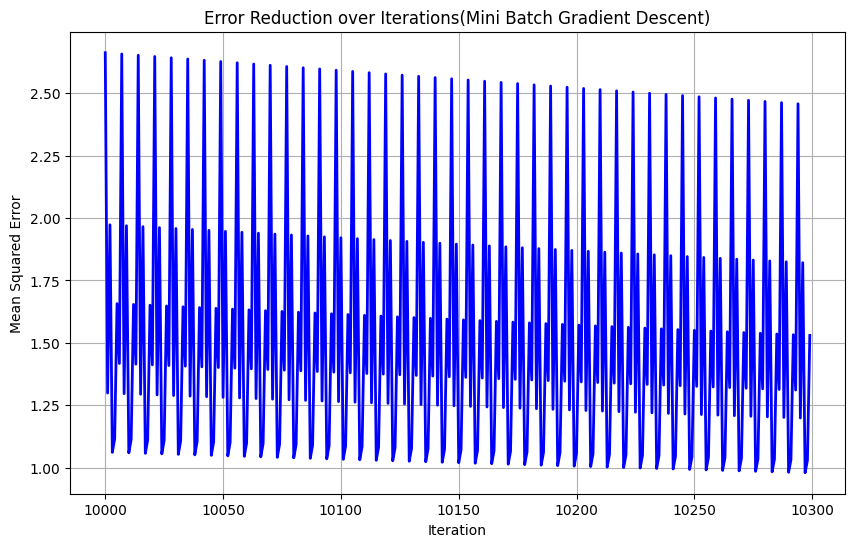

In [19]:
plot_loss(range(10000,10300), loss_history2[10000:10300], "Error Reduction over Iterations(Mini Batch Gradient Descent)")

Stochastic Gradient Descent

In [20]:
w1 = torch.rand(1, requires_grad = True)
w2 = torch.rand(1, requires_grad= True)
w3 = torch.rand(1, requires_grad= True)
bias = torch.rand(1, requires_grad= True)
w1,w2,w3,bias

(tensor([0.3577], requires_grad=True),
 tensor([0.7624], requires_grad=True),
 tensor([0.8570], requires_grad=True),
 tensor([0.2506], requires_grad=True))

In [21]:
learning_rate = 0.001
epochs = 500
n_samples = len(performance)

loss_history3 = []

for epoch in range(epochs):
  for i in range(n_samples):
    single_performance = performance[i]
    single_years_of_exp = years_of_exp[i]
    single_proj_completed = proj_completed[i]
    single_bonus = bonus[i]

    predicted_bonus3 = w1*single_performance + w2*single_years_of_exp + w3*single_proj_completed + bias

    loss3 = (predicted_bonus3 - single_bonus) **2

    if(i%10 ==0):
      loss_history3.append(loss3.item())

    loss3.backward()

    with torch.no_grad():
      w1 -= learning_rate * w1.grad
      w2 -= learning_rate * w2.grad
      w3 -= learning_rate * w3.grad
      bias -= learning_rate * bias.grad

    w1.grad.zero_()
    w2.grad.zero_()
    w3.grad.zero_()
    bias.grad.zero_()

  if(epoch+1)% 100 ==0:
      print(f"Epoch: [{epoch+1}/{epochs}], Loss:{loss3.item():.4f}")

print(f"w1 : {w1.item():.2f},w2: {w2.item():.2f},w3: {w3.item():.2f},bias: {bias.item():.2f}")

Epoch: [100/500], Loss:0.4625
Epoch: [200/500], Loss:0.0305
Epoch: [300/500], Loss:0.0020
Epoch: [400/500], Loss:0.0001
Epoch: [500/500], Loss:0.0000
w1 : 12.00,w2: 6.00,w3: 2.01,bias: 19.98


In [22]:
len(loss_history3)

5000

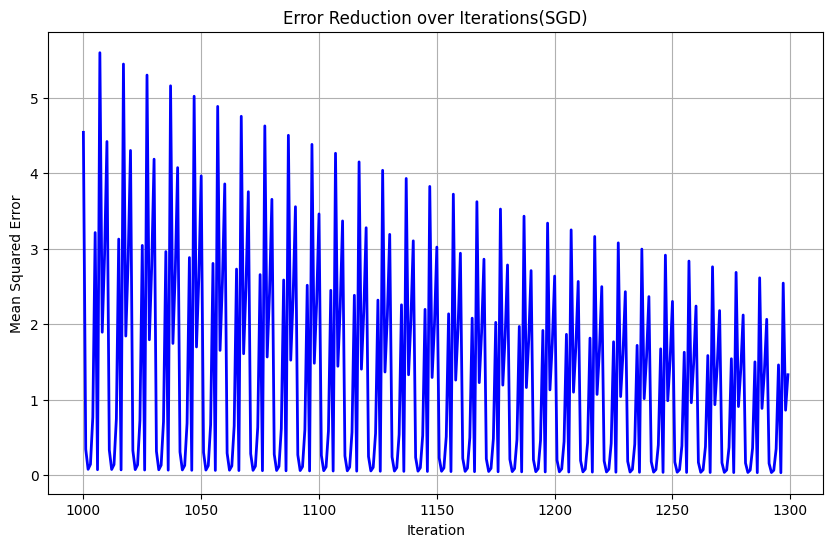

In [23]:
plot_loss(range(1000,1300), loss_history3[1000:1300], "Error Reduction over Iterations(SGD)")